In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
def cross_correlation_2d(img, kernel):
    '''Given a kernel of arbitrary m x n dimensions, with both m and n being
    odd, compute the cross correlation of the given image with the given
    kernel, such that the output is of the same dimensions as the image and that
    you assume the pixels out of the bounds of the image to be zero. Note that
    you need to apply the kernel to each channel separately, if the given image
    is an RGB image.

    Inputs:
        img:    Either an RGB image (height x width x 3) or a grayscale image
                (height x width) as a numpy array.
        kernel: A 2D numpy array (m x n), with m and n both odd (but may not be
                equal).

    Output:
        Return an image of the same dimensions as the input image (same width,
        height and the number of color channels)
    '''
    img_height, img_width = img.shape[:2]
    kernel_height, kernel_width = kernel.shape
    pad_h, pad_w = kernel_height // 2, kernel_width // 2
    
    # Padding
    if img.ndim == 3: # 3-dimensional image (with multiple channels)
        padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant')
    else: # 1-dimensional image (grayscale)
        padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    
    output = np.zeros_like(img)
    
    # Try a matrix multiplication approach?
    # Apply per pixel
    for i in range(img_height):
        for j in range(img_width):
            region = padded_img[i:i+kernel_height, j:j+kernel_width]
            if img.ndim == 3:
                output[i, j] = np.sum(region * kernel[..., np.newaxis], axis=(0, 1))
            else:
                output[i, j] = np.sum(region * kernel)

    return output

In [23]:
img = cv2.imread('resources/cat.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_rgb.shape

(361, 410, 3)

In [22]:
cross_correlation_2d(img_rgb, np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])).shape

(361, 410, 3)

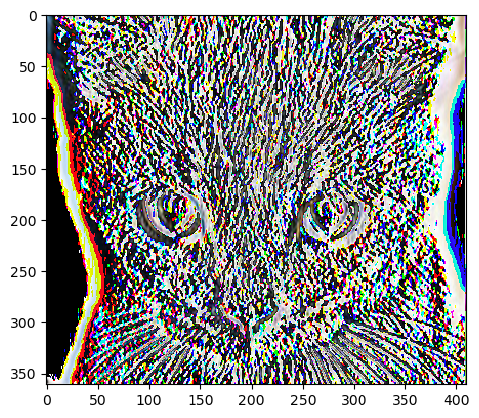

In [21]:
plt.imshow(cross_correlation_2d(img_rgb, np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])))

In [29]:
np.mgrid[-3: 3, -3: 3]

array([[[-3, -3, -3, -3, -3, -3],
        [-2, -2, -2, -2, -2, -2],
        [-1, -1, -1, -1, -1, -1],
        [ 0,  0,  0,  0,  0,  0],
        [ 1,  1,  1,  1,  1,  1],
        [ 2,  2,  2,  2,  2,  2]],

       [[-3, -2, -1,  0,  1,  2],
        [-3, -2, -1,  0,  1,  2],
        [-3, -2, -1,  0,  1,  2],
        [-3, -2, -1,  0,  1,  2],
        [-3, -2, -1,  0,  1,  2],
        [-3, -2, -1,  0,  1,  2]]])